# Proyek Klasifikasi Gambar: [Colors Dataset]
- **Nama:** [Refanda Surya Saputra]
- **Email:** [refandasuryasaputra@gmail.com]
- **ID Dicoding:** [refanda_surya]

## Import Semua Packages/Library yang Digunakan

In [2]:
# Melakukan import library
import os
import zipfile
import random
from importlib.metadata import distribution
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from PIL.ImageFilter import GaussianBlur
from tensorflow.python.keras.utils.metrics_utils import ConfusionMatrix
from tqdm.notebook import tqdm as tq
import matplotlib.pyplot as plt
import seaborn as sns

# Pustaka untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize, rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, multilabel_confusion_matrix
import tensorflow as tf
from keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, \
    Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

import warnings

warnings.simplefilter(action='ignore', category=FutureWarning)

import gdown

# Mencetak versi TensorFlow yang sedang digunakan
print(tf.__version__)

2.15.0


## Data Preparation

### Data Loading

**Data Preparation**

In [4]:
# ID File
file_id = "1F50w-PGnggX_cT9hs4Vpu8HUzt75VOlH"
url = f"https://drive.google.com/uc?id={file_id}"

# Unduh dalam bentuk zip
gdown.download(url, 'fruit-dataset.zip', quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1F50w-PGnggX_cT9hs4Vpu8HUzt75VOlH
To: /home/refanzzzz/PycharmProjects/colors-image-classification/fruit-dataset.zip
100%|██████████| 20.8M/20.8M [00:04<00:00, 4.97MB/s]


'fruit-dataset.zip'

In [9]:
# Unzip berkas yang telah diunduh dari google drive
with zipfile.ZipFile('fruit-dataset.zip', 'r') as zip_file:
    zip_file.extractall()

**Dataset Checking**

In [3]:
# Mengecek label pada dataset
fruit_path = "fruit-dataset"
list_label = os.listdir(fruit_path)

list_label

['strawberry',
 'mango',
 'banana',
 'orange',
 'apple',
 'kiwi',
 'cherry',
 'avocado',
 'watermelon',
 'pinenapple']

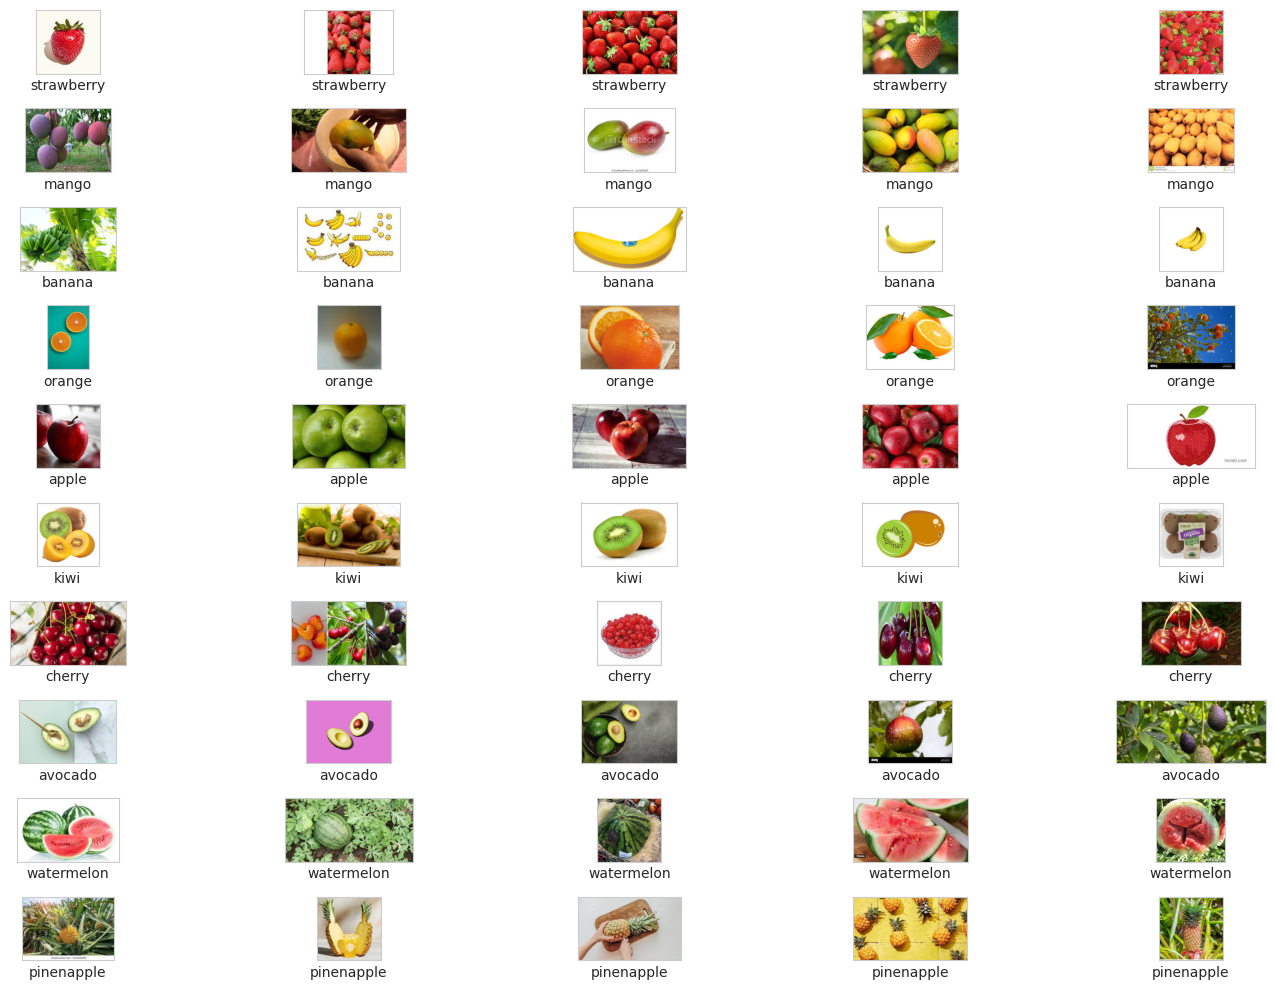

In [10]:
# Membuat dict yang menyimpan gambar untuk setiap kelas dalam data
fruit_image = {}

# Menentukan path sumber dataset
path = "fruit-dataset/"
for i in os.listdir(path):
    fruit_image[i] = os.listdir(path + i)

# Menampilkan secara acak 3 gambar di bawah hanya 10 kelas saja
fig, ax = plt.subplots(10, 5, figsize=[15, 10])

for i, class_name in enumerate(os.listdir(path)):
    images = np.random.choice(fruit_image[class_name], 5, replace=False)

    for j, image_name in enumerate(images):
        img_path = os.path.join(path, class_name, image_name)
        img = Image.open(img_path)
        ax[i, j].imshow(img)
        ax[i, j].set(xlabel=class_name, xticks=[], yticks=[])

fig.tight_layout()

In [11]:
# Membuat fungsi untuk melihat jumlah citra dan ukuran resolusi
def print_images_resoulution(directory):
    unique_sizes = set()
    total_images = 0

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        image_files = os.listdir(subdir_path)
        num_images = len(image_files)

        print(f"{subdir}: {num_images}")
        total_images += num_images

        for image_file in image_files:
            img_path = os.path.join(subdir_path, image_file)
            with Image.open(img_path) as img:
                unique_sizes.add(img.size)

        for size in unique_sizes:
            print(f"- {size}")

        print("------------------")

    print(f"\nTotal: {total_images}")


print_images_resoulution("fruit-dataset")

strawberry: 230
- (260, 194)
- (274, 184)
- (346, 145)
- (265, 190)
- (255, 198)
- (243, 208)
- (286, 176)
- (152, 331)
- (259, 195)
- (277, 182)
- (318, 159)
- (304, 166)
- (293, 172)
- (195, 259)
- (232, 217)
- (282, 178)
- (201, 251)
- (268, 188)
- (159, 318)
- (182, 277)
- (272, 186)
- (301, 167)
- (276, 183)
- (220, 166)
- (194, 260)
- (250, 201)
- (310, 163)
- (324, 156)
- (183, 275)
- (297, 169)
- (300, 168)
- (259, 194)
- (275, 184)
- (243, 207)
- (230, 219)
- (262, 193)
- (306, 165)
- (248, 203)
- (266, 190)
- (224, 224)
- (288, 175)
- (258, 195)
- (208, 243)
- (330, 153)
- (303, 166)
- (247, 204)
- (194, 259)
- (394, 128)
- (279, 181)
- (295, 171)
- (284, 177)
- (184, 273)
- (240, 210)
- (225, 225)
- (241, 209)
- (256, 197)
- (299, 168)
- (290, 174)
- (275, 183)
- (227, 222)
- (209, 241)
- (246, 205)
- (251, 201)
- (262, 192)
- (291, 173)
- (261, 193)
- (245, 206)
- (269, 188)
------------------
mango: 231
- (243, 208)
- (225, 224)
- (190, 266)
- (201, 251)
- (314, 161)
- (27

**Distribution Plot**

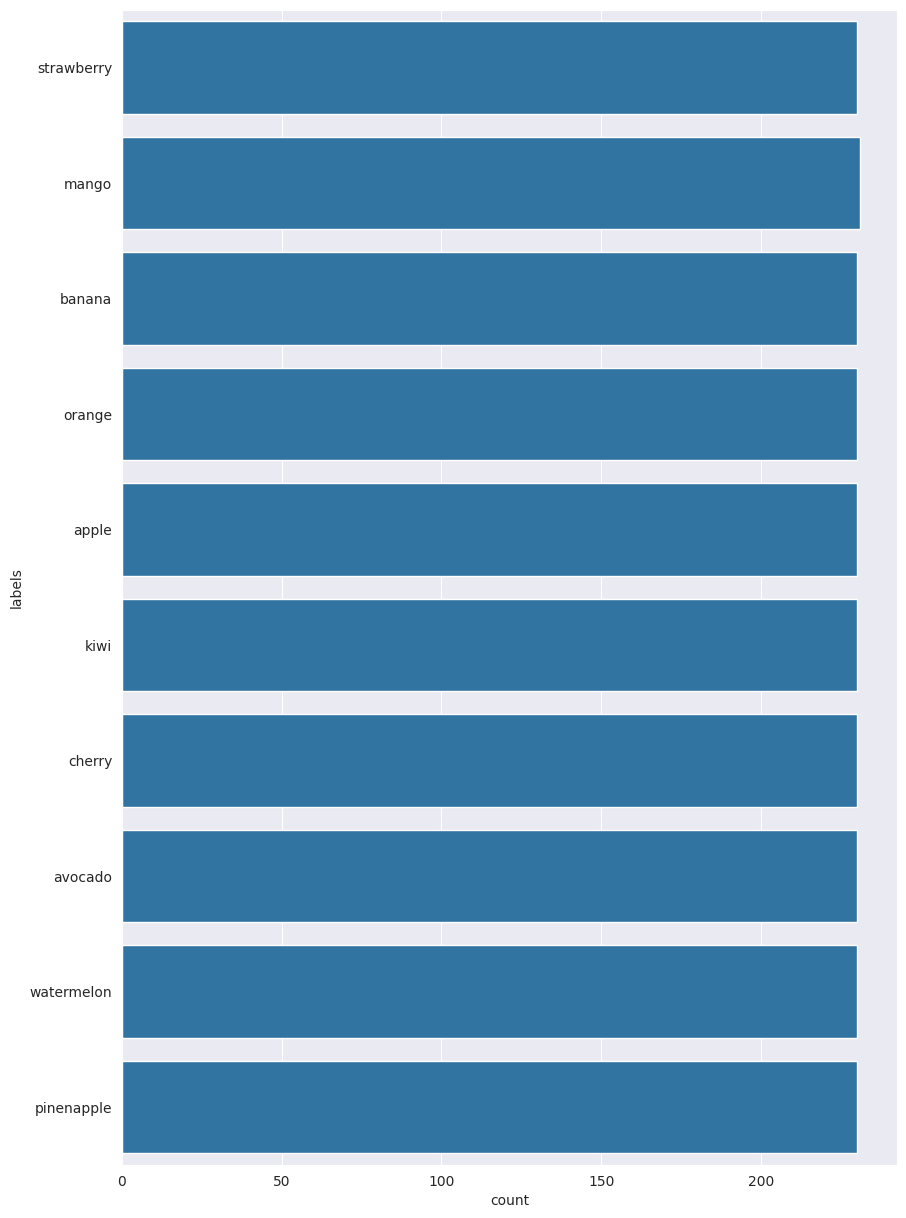

In [12]:
# Mendefinisikan path sumber
fruit_path = "fruit-dataset/"


def plot_distribution(dataset_path):
    # Membuat daftar yang menyimpan data untuk setiap nama file, path filem dan label dalam data
    file_name = []
    labels = []
    full_path = []

    # Mendapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai DataFrame
    for path, subdirs, files in os.walk(dataset_path):
        for name in files:
            full_path.append(os.path.join(path, name))
            labels.append(path.split('/')[-1])
            file_name.append(name)

    distribution_train = pd.DataFrame({
        'path': full_path,
        'file_name': file_name,
        'labels': labels
    })

    # Plot distribusi gambar setiap kelas
    label = distribution_train['labels']
    plt.figure(figsize=(10, 15))
    sns.set_style("darkgrid")
    sns.countplot(label)


plot_distribution(fruit_path)

### Data Preprocessing

#### Augmentation Data

In [13]:
# Membuat fungsi untuk melakukan rotasi berlawanan arah jaruh jam
def anticlockwise_rotation(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    angle = random.randint(0, 180)
    return rotate(img, angle)


# Membuat fungsi untuk melakukan rotasi searah jarum jam
def clockwise_rotation(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    angle = random.randint(0, 180)
    return rotate(img, -angle)


# Membuat fungsi untuk memberikan efek peningkatan kecerahan pada gambar
def add_brightness(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    img = adjust_gamma(img, gamma=0.5, gain=1.0)
    return img


# Membuat fungsi untuk membalik gambar secara vertikal dari atas ke bawah
def flip_up_down(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    return np.flipud(img)


# Membuat fungsi untuk memberikan efek pergeseran acak pada gambar
def sheared(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    transform = AffineTransform(shear=0.2)
    shear_img = warp(img, transform, mode='wrap')
    return shear_img


# Membuat fungsi untuk melakukan pergeseran melengkung pada gambar
def warp_shift(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    transform = AffineTransform(translation=(0, 40))
    warp_image = warp(img, transform, mode='wrap')
    return warp_image


# Membuat fungsi untuk memberikan efek blur pada gambar
def blur_image(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    return cv2.GaussianBlur(img, (9, 9), 0)


# Membuat fungsi untuk menambahkan noise pada gambar
def add_noise(img):
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    img = cv2.resize(img, (224, 224))
    gauss = np.random.normal(0, 0.7, img.shape)
    gauss = gauss.astype('uint8')
    img = cv2.add(img, gauss)
    return img

In [14]:
# Membuat variabel transformasi yang akan menyimpan semua proses pra-pemrosesan yang telah dilakukan sebelumnya
transformations = {
    'rotation anticlockwise': anticlockwise_rotation,
    'rotation clockwise': clockwise_rotation,
    'warp shift': warp_shift,
    'blurring image': blur_image,
    'add brightness': add_brightness,
    'flip up down': flip_up_down,
    'sheared': sheared,
    'noise image': add_noise,
}


def generate_augmented_image(original_image_path, augmented_path):
    # Penyimpanan gambar yang telah melalui pra-pemrosesan
    processed_images = []

    # Membaca nama gambar dari folder dan tambahkan path ke dalam array "images"
    for img in os.listdir(original_image_path):
        processed_images.append(os.path.join(original_image_path, img))

    # Jumlah gambar yang akan ditambahkan dengan hasil transformasi augmentasi, jumlahnya disesuaikan sesuai kebutuhan
    # variabel untuk melakukan iterasi sampai jumlah gambar yang ditentukan dalam images_to_generate
    images_to_generate = 170
    i = 1

    while i <= images_to_generate:
        random_image = random.choice(processed_images)
        try:
            original_image = io.imread(random_image)
            transformed_image = None

            # Variabel untuk melakukan iterasi sampai jumlah transformasi yang akan diterapkan
            n = 0
            transformation_count = random.randint(1, len(transformations))

            while n <= transformation_count:
                # Secara acak memilih dan memanggil metode
                key = random.choice(list(transformations))
                transformed_image = transformations[key](original_image)
                n = n + 1

            if not os.path.exists(augmented_path):
                os.makedirs(augmented_path)

            new_image_path = "%s/augmented_image_%s.jpg" % (augmented_path, i)
            transformed_image = img_as_ubyte(transformed_image)
            cv2.imwrite(new_image_path, transformed_image)
            i = i + 1
        except Exception as e:
            print('could not read the', image, ':', e, 'hence skipping it.')

In [15]:
# Melakukan augmentasi untuk beberapa class yang masih minoritas
for cm in list_label:
    generate_augmented_image(original_image_path=f"fruit-dataset/{cm}", augmented_path=f"fruit-dataset/{cm}")

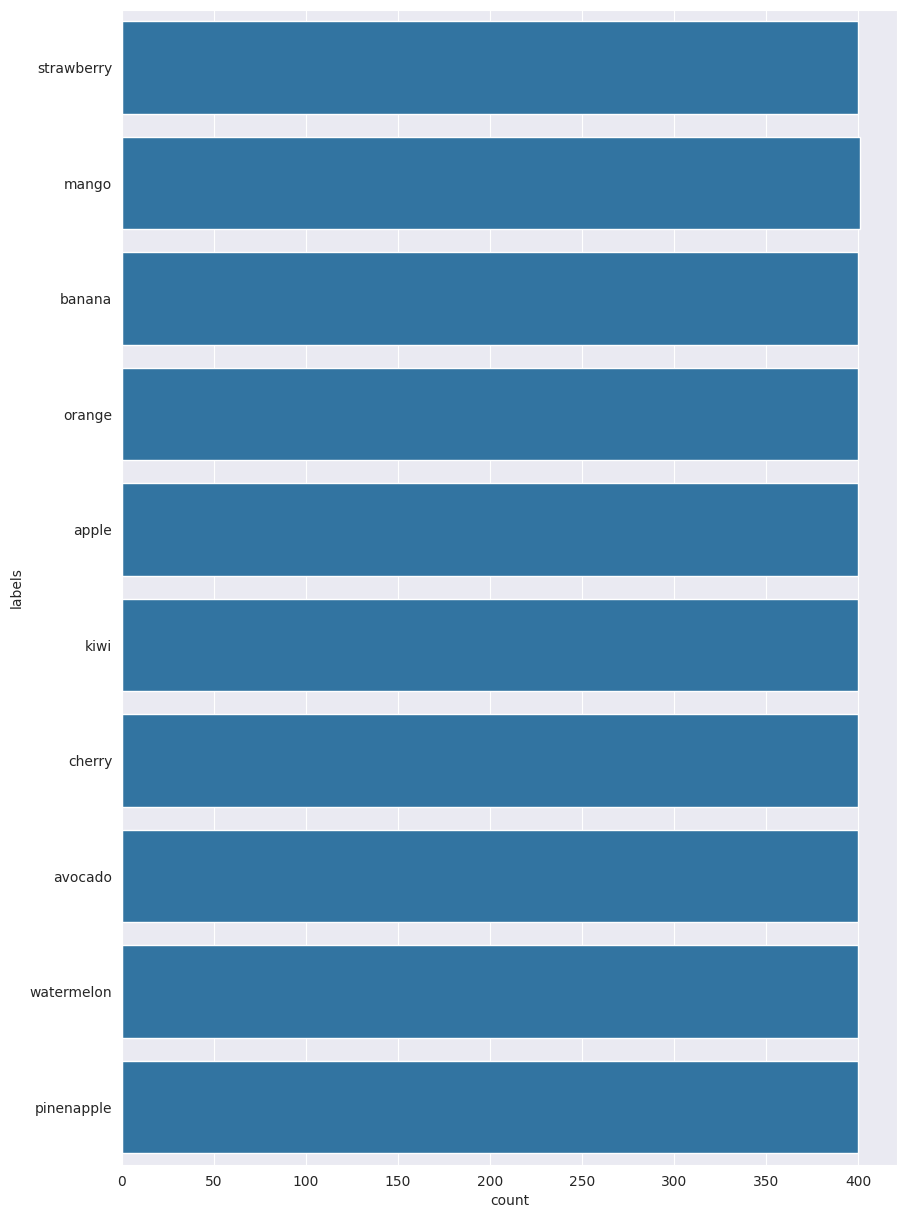

In [16]:
# Melihat plot distribusi kelas setelah dilakukan augmentasi
plot_distribution(fruit_path)

#### Split Dataset

In [17]:
# Membuat variabel yang menampung lokasi folder dari dataset gambar
my_path = 'fruit-dataset/'

file_name = []
labels = []
full_path = []

for path, subdirs, files in os.walk(my_path):
    for name in files:
        full_path.append(os.path.join(path, name))
        labels.append(path.split('/')[-1])
        file_name.append(name)

# Memasukkan variabel yang sudah dikumpulkan pada looping di atas menjadi sebuah DataFrame
df = pd.DataFrame({
    "path": full_path,
    "file_name": file_name,
    "labels": labels
})

# Melihat jumlah data gambar pada masing-masing label
df.groupby(by='labels').size()

labels
apple         400
avocado       400
banana        400
cherry        400
kiwi          400
mango         401
orange        400
pinenapple    400
strawberry    400
watermelon    400
dtype: int64

In [18]:
# Variabel yang digunakan pada pemisahan data ini, di aman variabel x = data path dan y = data labels
X = df['path']
y = df['labels']

# Split dataset awal menjadi data train dan temp (test dan validasi)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Menyatukan ke dalam masing-masing DataFrame
df_train = pd.DataFrame({
    'path': X_train,
    'labels': y_train,
    'set': 'train'
})

df_test = pd.DataFrame({
    'path': X_test,
    'labels': y_test,
    'set': 'test'
})

df_validation = pd.DataFrame({
    'path': X_val,
    'labels': y_val,
    'set': 'validation'
})

# Menggabungkan DataFrame df_train, df_test, dan df_validation
df_all = pd.concat([df_train, df_test, df_validation], ignore_index=True)

print("======================================================\n")
print(df_all.groupby(['set', 'labels']).size(), '\n')
print("======================================================\n")

# Mengecek sampel data
print(df_all.sample(5))

# Memanggil dataset asli yang berisi keseluruhan data gambr yang sesuai dengan labelnya
datasource_path = "fruit-dataset/"

# Membuat variabel Dataset, tempat menampung data yang telah dilakukan pembagian data training dan testing
dataset_path = "dataset-final/"


set         labels    
test        apple          60
            avocado        60
            banana         60
            cherry         60
            kiwi           60
            mango          61
            orange         60
            pinenapple     60
            strawberry     60
            watermelon     60
train       apple         280
            avocado       280
            banana        280
            cherry        280
            kiwi          280
            mango         280
            orange        280
            pinenapple    280
            strawberry    280
            watermelon    280
validation  apple          60
            avocado        60
            banana         60
            cherry         60
            kiwi           60
            mango          60
            orange         60
            pinenapple     60
            strawberry     60
            watermelon     60
dtype: int64 


                                             path      label

In [19]:
for index, row in tq(df_all.iterrows()):
    # Deteksi filepath
    file_path = row['path']
    if os.path.exists(file_path) == False:
        file_path = os.path.join(datasource_path, row['labels'], row['image'].split('.')[0])

    # Membuat direktori tujuan folder
    if os.path.exists(os.path.join(dataset_path, row['set'], row['labels'])) == False:
        os.makedirs(os.path.join(dataset_path, row['set'], row['labels']))

    # Menentukan tujuan file
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_path, row['set'], row['labels'], destination_file_name)

    # Menyalin file dari sumber ke tujuan
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path, file_dest)

0it [00:00, ?it/s]

#### Image Data Generator

In [20]:
# Definisikan direktori training, test, dan validation
TRAIN_DIR = "dataset-final/train/"
TEST_DIR = "dataset-final/test/"
VALIDATION_DIR = "dataset-final/validation/"


# Membuat fungsi untuk menampilkan jumlah data train berdasarkan label
def print_total_train_data(label):
    train_temp = os.path.join(TRAIN_DIR, label)
    print(f"Total number of {label} images in training set: {len(os.listdir(train_temp))}")


# Membuat fuungsi untuk menampilkan jumlah data test berdasakran label
def print_total_test_data(label):
    test_temp = os.path.join(TEST_DIR, label)
    print(f"Total number of {label} images in test set: {len(os.listdir(test_temp))}")


# Membuat fungsi untuk menampilkan jumlah data validasi berdasarkan label
def print_total_validation_data(label):
    val_temp = os.path.join(VALIDATION_DIR, label)
    print(f"Total number of {label} images in validation set: {len(os.listdir(val_temp))}")


label_list = y.unique()

for label in label_list:
    print_total_train_data(label)
    print_total_test_data(label)
    print_total_validation_data(label)
    print("------------------------------------------------------------")

Total number of strawberry images in training set: 280
Total number of strawberry images in test set: 60
Total number of strawberry images in validation set: 60
------------------------------------------------------------
Total number of mango images in training set: 280
Total number of mango images in test set: 61
Total number of mango images in validation set: 60
------------------------------------------------------------
Total number of banana images in training set: 280
Total number of banana images in test set: 60
Total number of banana images in validation set: 60
------------------------------------------------------------
Total number of orange images in training set: 280
Total number of orange images in test set: 60
Total number of orange images in validation set: 60
------------------------------------------------------------
Total number of apple images in training set: 280
Total number of apple images in test set: 60
Total number of apple images in validation set: 60
-----

In [21]:
# Membuat objek ImageDataGenerator yang untuk menormalisasikan gambar
datagen = ImageDataGenerator(rescale=1. / 255)
test_datagen = ImageDataGenerator(rescale=1. / 255)
val_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = datagen.flow_from_directory(
    TRAIN_DIR,
    seed=42,
    batch_size=32,
    target_size=(150, 150),
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    VALIDATION_DIR,
    seed=42,
    batch_size=32,
    target_size=(150, 150),
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    seed=42,
    batch_size=1,
    target_size=(150, 150),
    class_mode='categorical',
    shuffle=False
)

Found 2800 images belonging to 10 classes.
Found 600 images belonging to 10 classes.
Found 601 images belonging to 10 classes.


## Modelling

In [22]:
# Init sequential model
model_1 = Sequential()

# 1st Convolutional layer, Batch Normalization, dan Pooling layer
model_1.add(Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3), padding='same'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Dropout(0.3))

# 2nd Concolutional Layer, Batch Normalization layer, dan Pooling layer
model_1.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Dropout(0.4))

# 2nd Concolutional Layer, Batch Normalization layer, dan Pooling layer
model_1.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model_1.add(BatchNormalization())
model_1.add(MaxPooling2D(pool_size=(2, 2)))
model_1.add(Dropout(0.5))

# Flatten layer
model_1.add(Flatten())
model_1.add(Dense(128, activation='relu'))
model_1.add(BatchNormalization())
model_1.add(Dropout(0.5))

model_1.add(Dense(64, activation='relu'))
model_1.add(BatchNormalization())
model_1.add(Dropout(0.5))

model_1.add(Dense(len(label_list), activation='softmax'))

model_1.compile(optimizer=tf.keras.optimizers.Adam(),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# Rangkuman arsitektur model
print(model_1.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 150, 150, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 150, 150, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 75, 75, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 75, 75, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 75, 75, 64)        18496     
                                                                 
 batch_normalization_1 (Bat  (None, 75, 75, 64)        2

In [23]:
# Membuat fungsi untuk menghitung bobot pada masing-masing class
def calculate_weight(label_list):
    weight_dict = dict()

    sum_train = 0

    for target in label_list:
        path = os.path.join(TRAIN_DIR, target)
        count_train = len(os.listdir(path))
        sum_train += count_train

    for i, target in enumerate(label_list):
        path = os.path.join(TRAIN_DIR, target)
        count_train = len(os.listdir(path))
        weight = (1 / count_train) * sum_train / len(label_list)
        weight_dict[i] = weight

    return weight_dict


class_weights = calculate_weight(label_list)

%time

# Membuat callback
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


# Membuat custom callback untuk menghentikan pelatihan model saat akurasi lebih dari 95%
class EpochCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if (logs.get('accuracy') > 0.95):
            print("\nAkurasi telah mencapai >95%!")
            self.model.stop_training = True


epoch_end = EpochCallback()

# Fitting / training model
history_1 = model_1.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    class_weight=class_weights,
    callbacks=[checkpoint, early_stopping, epoch_end]
)

CPU times: user 4 µs, sys: 1 µs, total: 5 µs
Wall time: 7.87 µs
Epoch 1/30
88/88 [==============================] - 53s 572ms/step - loss: 2.9554 - accuracy: 0.1568 - val_loss: 9.4421 - val_accuracy: 0.1000
Epoch 2/30


/home/refanzzzz/miniconda3/envs/colors-image-classification/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


88/88 [==============================] - 58s 651ms/step - loss: 2.2840 - accuracy: 0.2389 - val_loss: 5.5971 - val_accuracy: 0.1133
Epoch 3/30
88/88 [==============================] - 46s 524ms/step - loss: 1.9534 - accuracy: 0.3150 - val_loss: 4.2481 - val_accuracy: 0.1283
Epoch 4/30
88/88 [==============================] - 46s 525ms/step - loss: 1.7639 - accuracy: 0.3464 - val_loss: 3.7586 - val_accuracy: 0.1450
Epoch 5/30
88/88 [==============================] - 51s 574ms/step - loss: 1.6438 - accuracy: 0.3907 - val_loss: 5.2461 - val_accuracy: 0.1650
Epoch 6/30
88/88 [==============================] - 52s 596ms/step - loss: 1.5449 - accuracy: 0.4314 - val_loss: 3.3831 - val_accuracy: 0.2733
Epoch 7/30
88/88 [==============================] - 46s 518ms/step - loss: 1.4548 - accuracy: 0.4525 - val_loss: 2.3488 - val_accuracy: 0.3683
Epoch 8/30
88/88 [==============================] - 43s 489ms/step - loss: 1.3837 - accuracy: 0.4882 - val_loss: 1.7294 - val_accuracy: 0.4383
Epoch 9/30

## Evaluasi dan Visualisasi

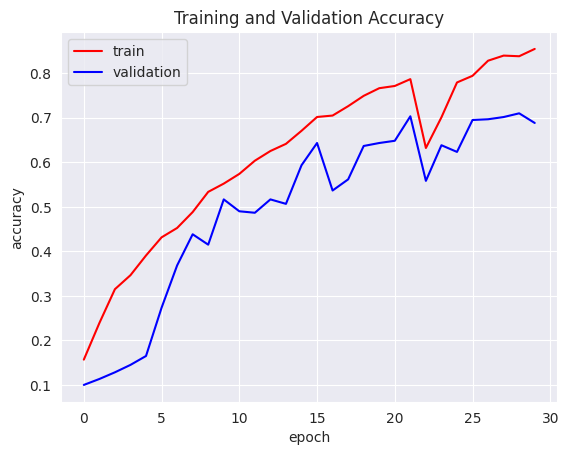

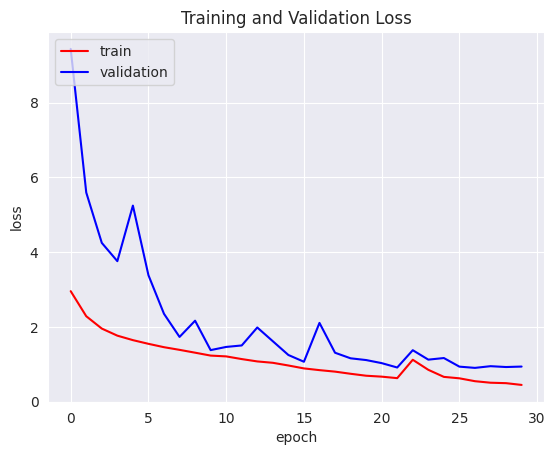

In [24]:
acc = history_1.history['accuracy']
val_acc = history_1.history['val_accuracy']
loss = history_1.history['loss']
val_loss = history_1.history['val_loss']

epochs = range(len(acc))


def plot_model_result(epochs, acc, val_acc, loss, val_loss):
    plt.plot(epochs, acc, 'r')
    plt.plot(epochs, val_acc, 'b')
    plt.title('Training and Validation Accuracy')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()

    plt.plot(epochs, loss, 'r')
    plt.plot(epochs, val_loss, 'b')
    plt.ylabel('loss')
    plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.title('Training and Validation Loss')
    plt.show()


plot_model_result(epochs, acc, val_acc, loss, val_loss)

In [25]:
# Evaluasi model menggunakan data pengujian
evaluation = model_1.evaluate(
    test_generator
)

# Menampilkan hasil evaluasi
print("Loss:", evaluation[0])
print("Accuracy:", evaluation[1])

601/601 [==============================] - 4s 7ms/step - loss: 1.0767 - accuracy: 0.6606
Loss: 1.0767377614974976
Accuracy: 0.6605657339096069


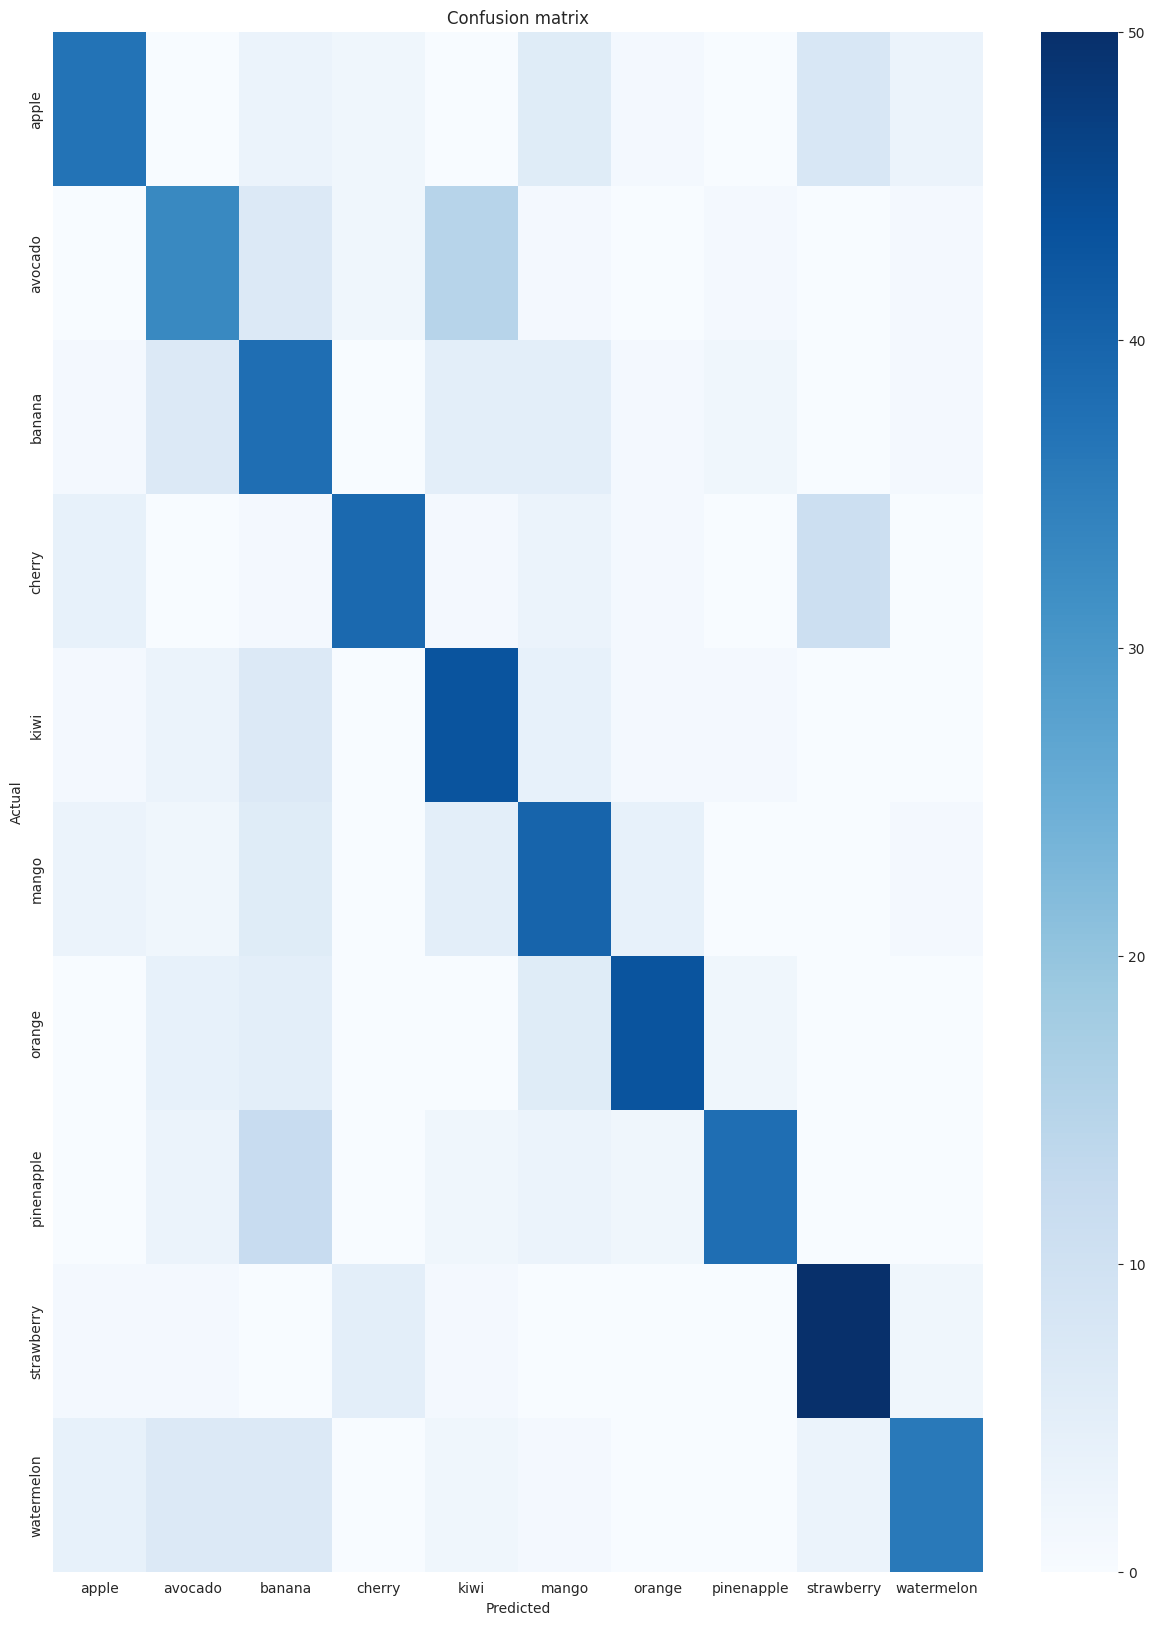

In [26]:
test_generator.reset()

preds_1 = model_1.predict(test_generator, verbose=0)
y_pred = preds_1.argmax(axis=1)
y_true = test_generator.classes
class_names = list(test_generator.class_indices.keys())

# Tampilkan confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15, 20))
sns.heatmap(cm, annot=False, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion matrix')
plt.show()

In [27]:
# Tampilkan classification report
print("\n")
print(classification_report(y_true, y_pred, target_names=label_list, zero_division=0))



              precision    recall  f1-score   support

  strawberry       0.73      0.62      0.67        60
       mango       0.55      0.55      0.55        60
      banana       0.44      0.63      0.52        60
      orange       0.81      0.65      0.72        60
       apple       0.58      0.72      0.64        60
        kiwi       0.58      0.66      0.62        61
      cherry       0.81      0.72      0.76        60
     avocado       0.86      0.63      0.73        60
  watermelon       0.69      0.83      0.76        60
  pinenapple       0.82      0.60      0.69        60

    accuracy                           0.66       601
   macro avg       0.69      0.66      0.67       601
weighted avg       0.69      0.66      0.67       601



## Konversi Model

In [29]:
# Konversi model ke format SavedModel
save_path = 'submission/saved_model'
tf.saved_model.save(model_1, save_path)

INFO:tensorflow:Assets written to: submission/saved_model/assets


INFO:tensorflow:Assets written to: submission/saved_model/assets


In [46]:
# Konversi model ke TensorFlow.js
!tensorflowjs_converter \
--input_format=tf_saved_model \
                 /home/refanzzzz/PycharmProjects/colors-image-classification/submission/saved_model/ \
                 /home/refanzzzz/PycharmProjects/colors-image-classification/submission/tfjs_model

2025-05-03 05:57:45.736681: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-03 05:57:45.737670: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-03 05:57:45.744344: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-03 05:57:45.762978: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746226665.794974   10717 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746226665.80

In [48]:
# Konversi model ke TensorFlowLite
converter = tf.lite.TFLiteConverter.from_saved_model("submission/saved_model")
tflite_model = converter.convert()

with tf.io.gfile.GFile('submission/tflite/fruit_model.tflite', 'wb') as f:
    f.write(tflite_model)

2025-05-03 06:00:57.364774: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2025-05-03 06:00:57.364811: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2025-05-03 06:00:57.365100: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: submission/saved_model
2025-05-03 06:00:57.369630: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2025-05-03 06:00:57.369664: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: submission/saved_model
2025-05-03 06:00:57.380927: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2025-05-03 06:00:57.507610: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: submission/saved_model
2025-05-03 06:00:57.540133: I tensorflow/cc/saved_model/loader.cc:316] SavedModel load for tags { serve }; Status: success

## Inference (Optional)